# CBE423 Assignment 1
Kevin Park

---
## 1

In [2]:
# Obtain the number of materials for each possible site count (1 to 100)

from mp_api.client import MPRester

api_key = input("Enter your Materials Project API key: ")

counts = [0]*100

with MPRester(api_key) as mpr:
    for doc in mpr.materials.search(fields=["nsites"],all_fields=False,num_sites=[1,100]):
        n = getattr(doc, "nsites")
        counts[n-1] += 1

    print(counts)

Retrieving MaterialsDoc documents:   0%|          | 0/146911 [00:00<?, ?it/s]

[204, 1767, 1755, 12385, 4063, 5512, 1633, 5748, 2508, 8231, 1514, 6456, 2452, 4891, 1820, 7216, 1018, 4054, 1807, 5909, 850, 3166, 552, 5743, 621, 1822, 439, 5792, 770, 2056, 343, 4503, 281, 1118, 269, 4169, 369, 1274, 279, 4130, 253, 1288, 180, 2094, 268, 945, 106, 2375, 151, 668, 87, 1689, 70, 757, 103, 2059, 72, 415, 71, 1142, 34, 356, 129, 1856, 92, 332, 31, 937, 80, 365, 38, 1272, 35, 194, 50, 735, 65, 283, 55, 1635, 46, 142, 41, 655, 24, 220, 27, 656, 23, 263, 17, 429, 16, 155, 29, 606, 20, 112, 21, 553]


Text(0.5, 1.0, '$n_{RoF}$=76966, $n_{non-RoF}$=69945')

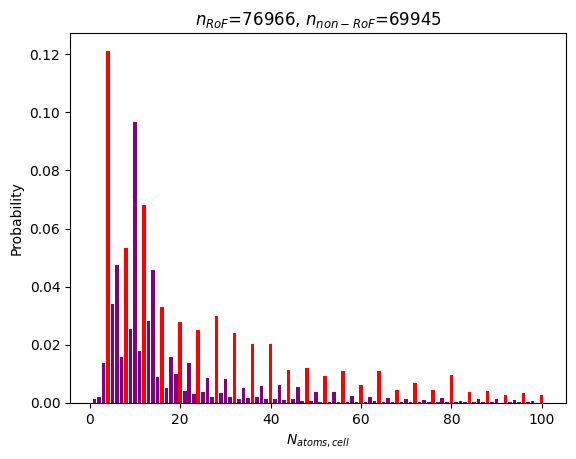

In [13]:
# Process and graph obtained results

import matplotlib.pyplot as plt
import numpy as np

colors = []
n_RoF = 0
n_non_RoF = 0
for i in range(len(counts)):
    if (i+1) % 4 == 0:
        colors.append('red')
        n_RoF += counts[i]
    else:
        colors.append('purple')
        n_non_RoF += counts[i]

normcounts = counts/sum(np.array(counts))

plt.bar(range(1,101), normcounts, color=colors)
plt.xlabel("$N_{atoms,cell}$")
plt.ylabel("Probability")
plt.title("$n_{RoF}$="+str(n_RoF)+", $n_{non-RoF}$="+str(n_non_RoF))

---
## 2

### 2.1

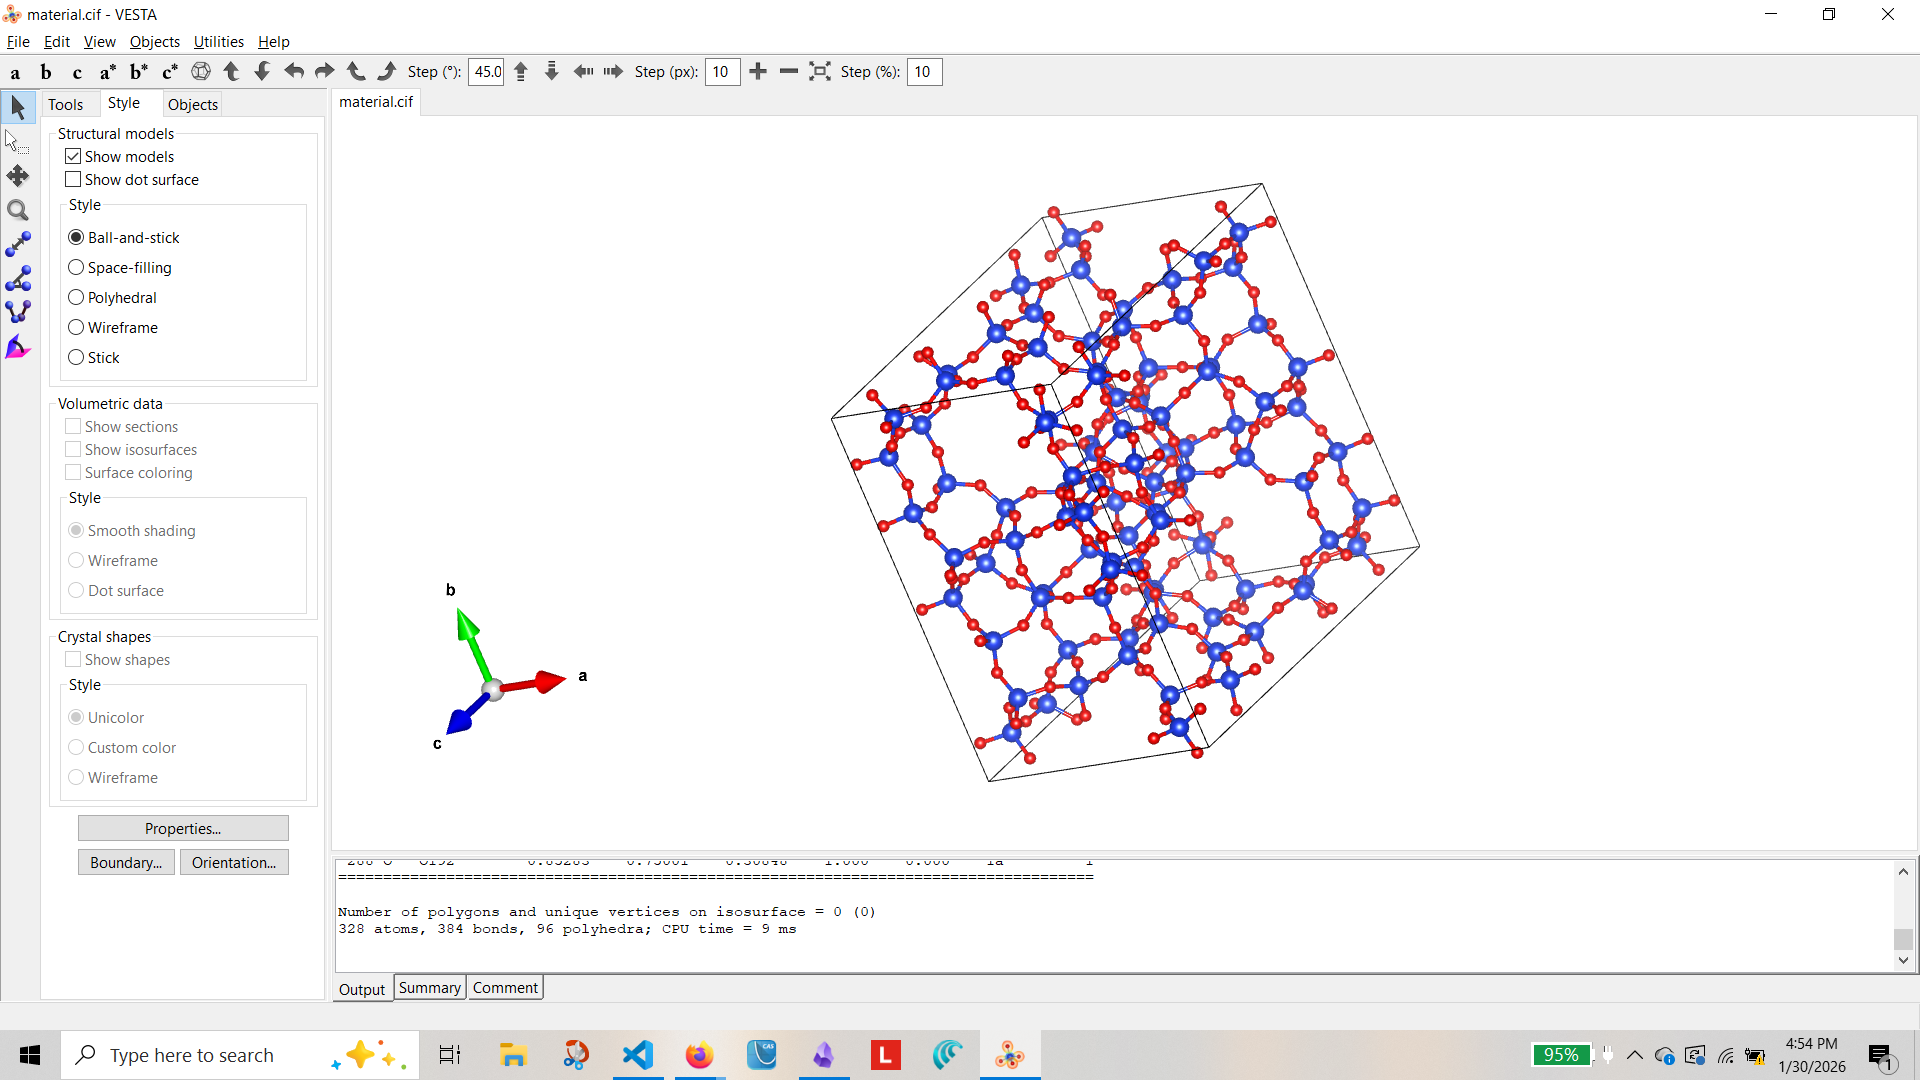

### 2.2

The Materials Project Crystal Toolkit provided crystal system, hall number, international number, and symbol. Using this information I searched for materials with the chemical formula SiO2 (also from the Crystal Toolkit), which yielded 6 results. I used the VESPA powder XRD calculator to obtain a spectra with a peak at intensities of 100 and 26. One result had a powder XRD that distinctly matched the VESPA result: mp-1204070. 

### 2.3

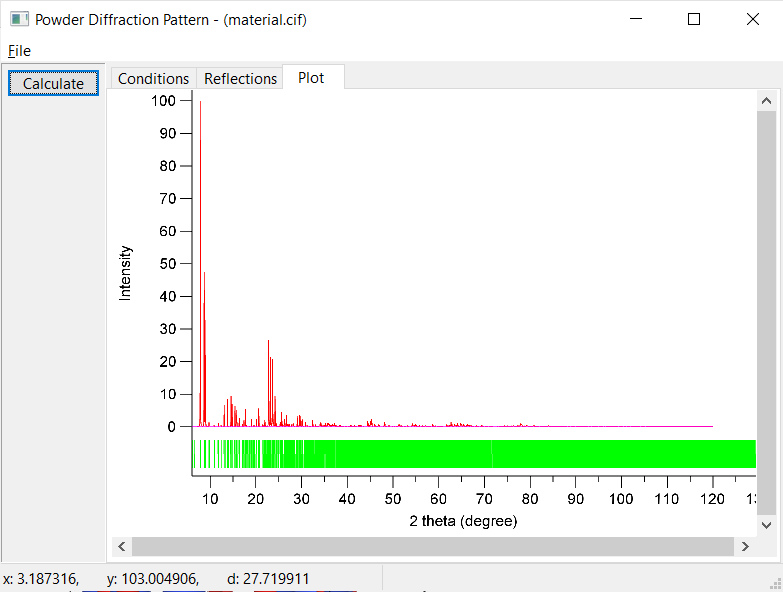

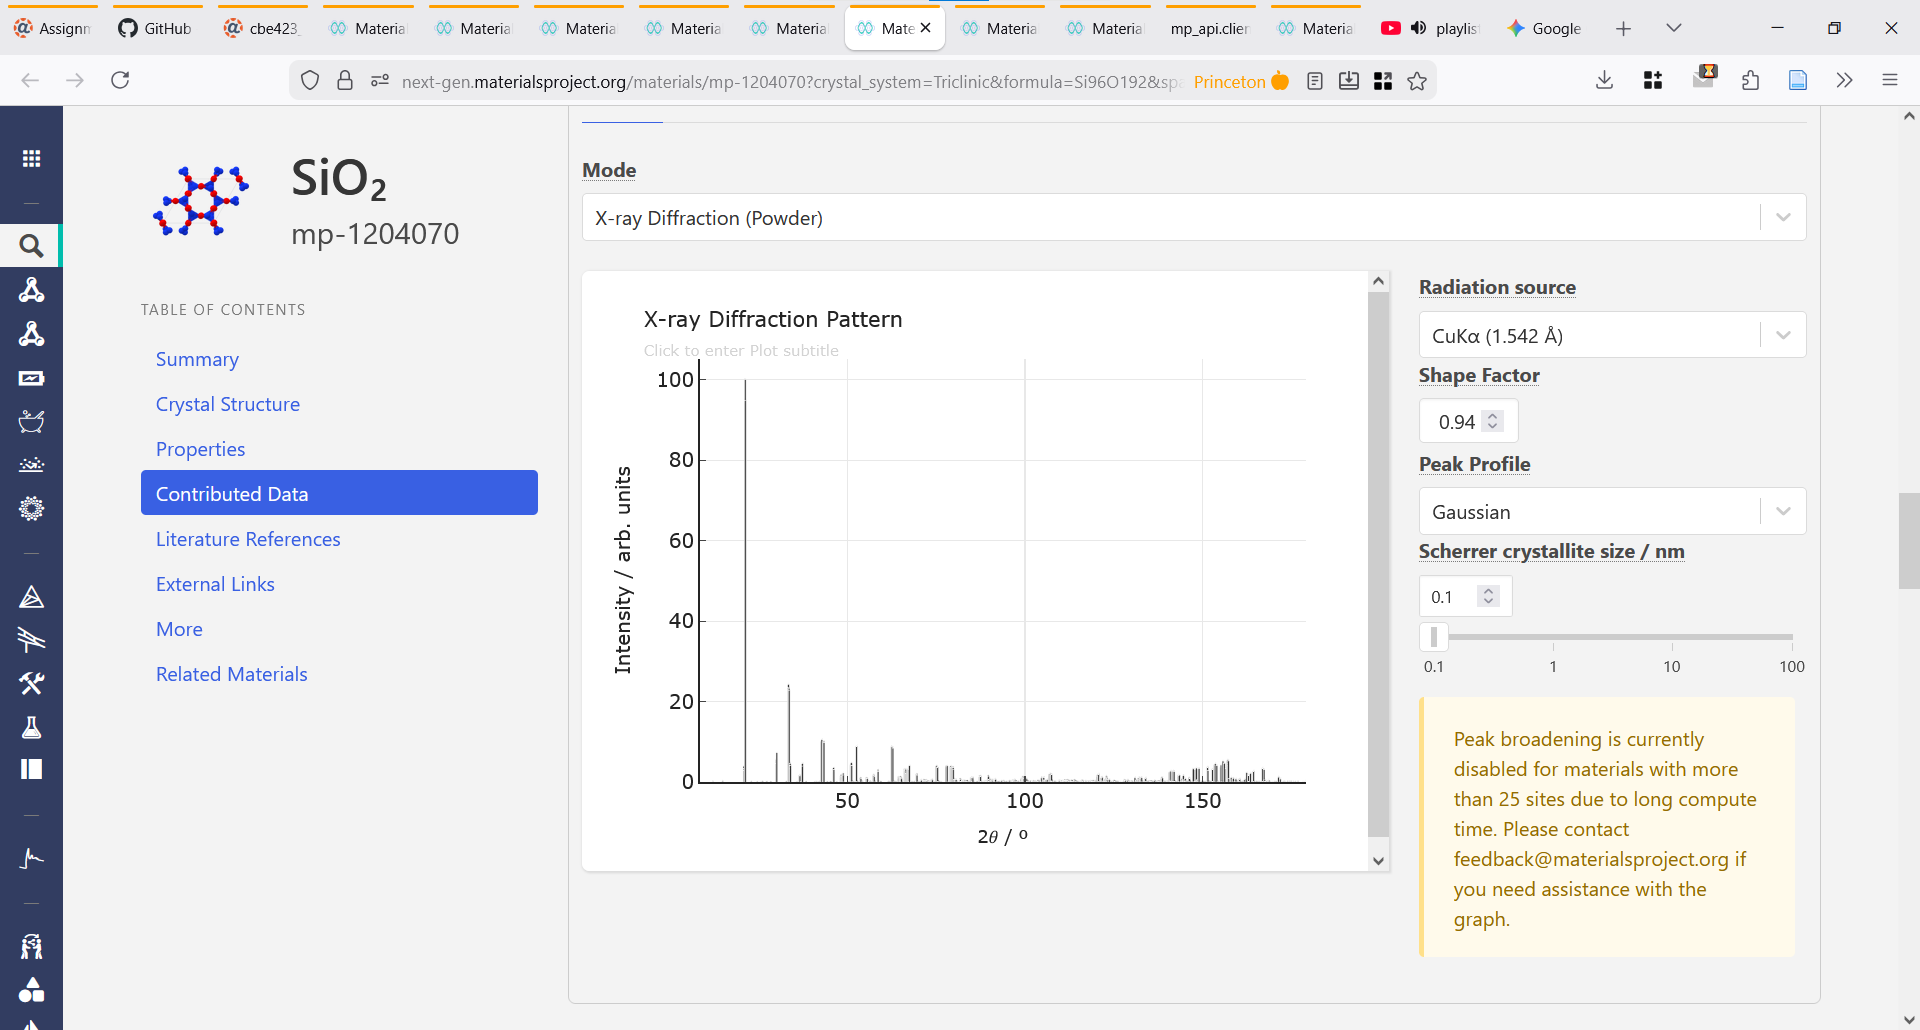

---
## 3

### 3.1

Sodalite

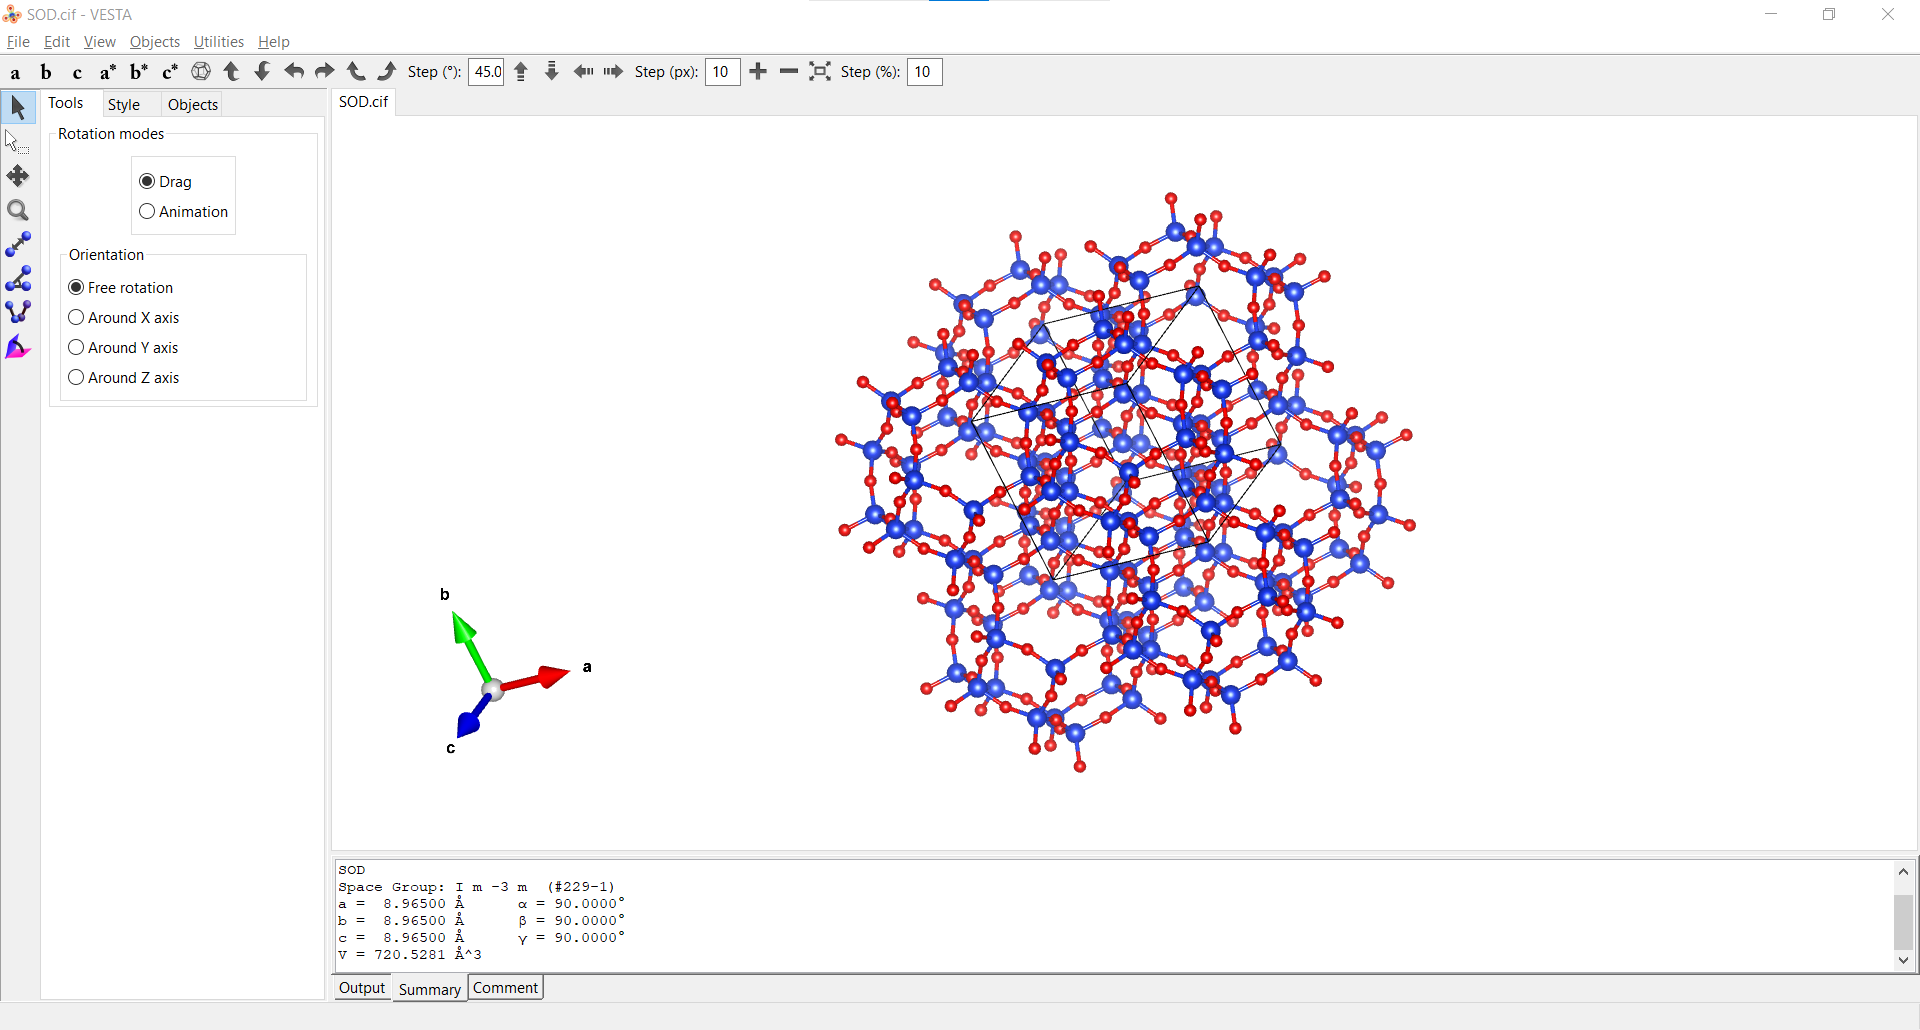

Quartz

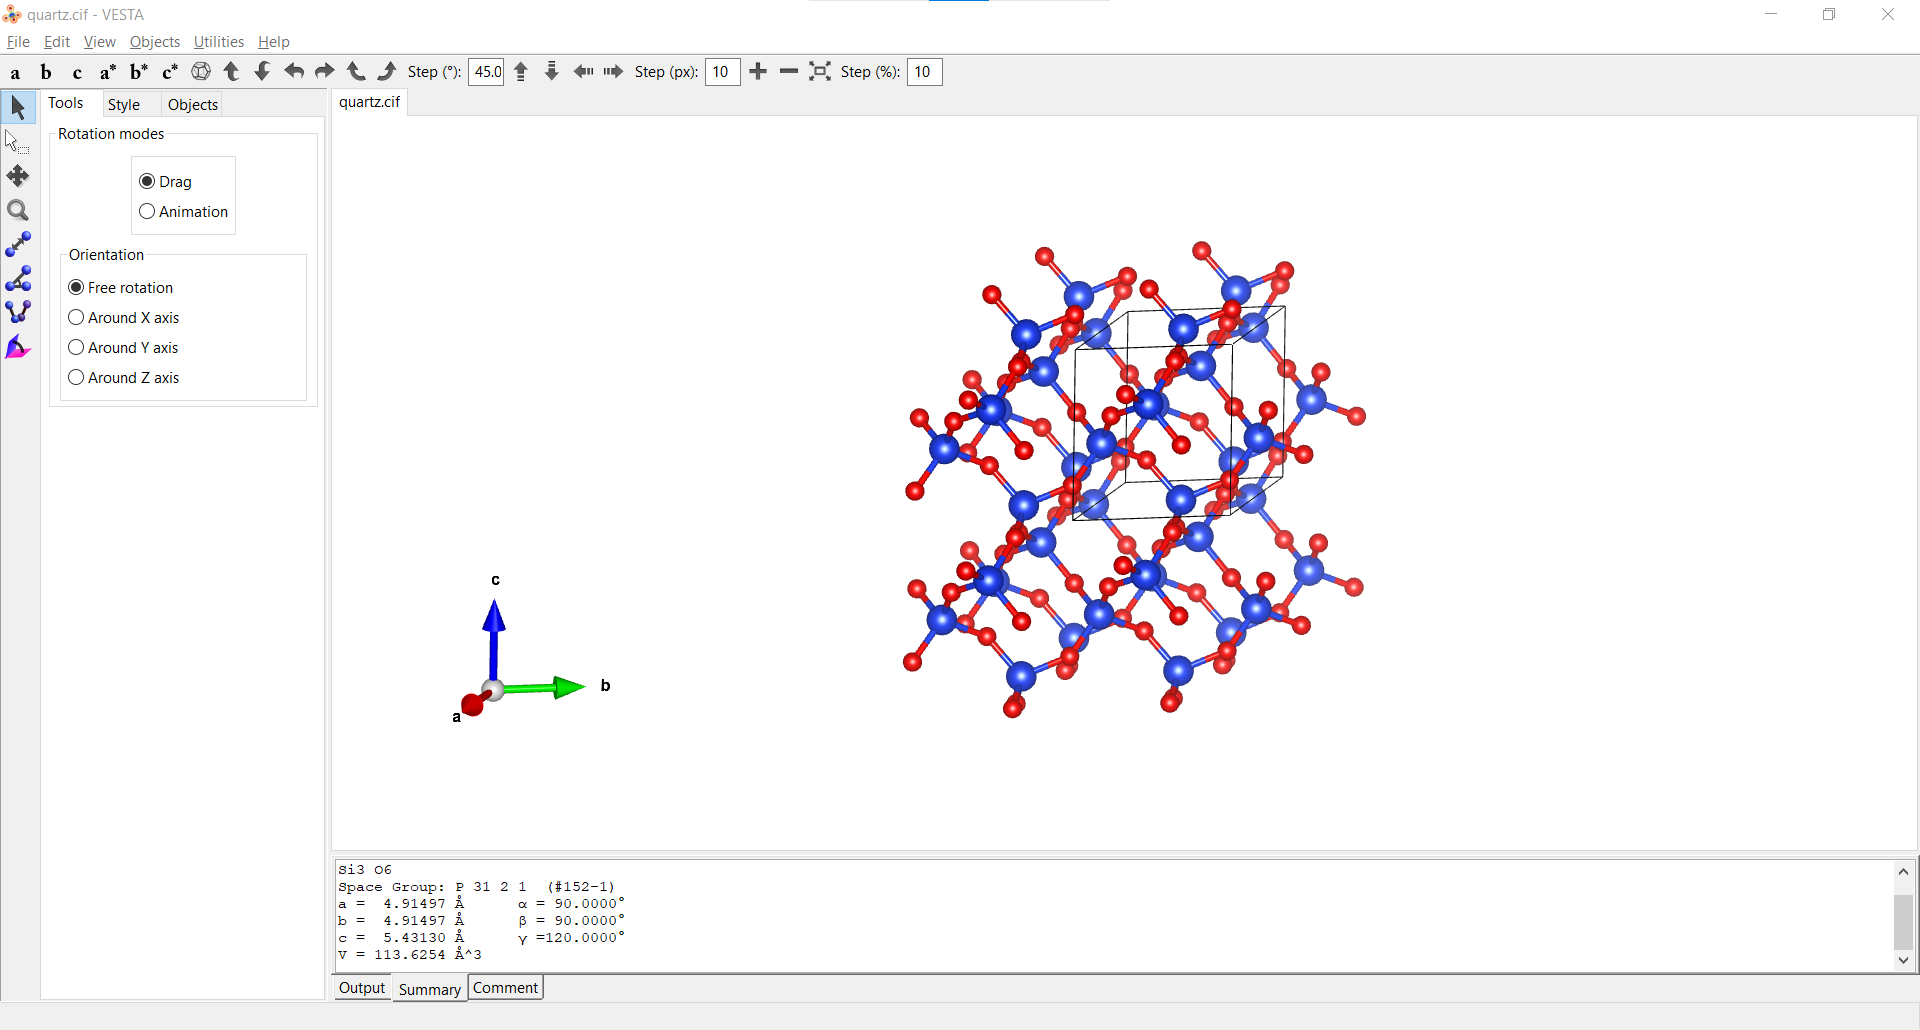

### 3.2

In [8]:
from matcalc import load_fp

calc = load_fp("TensorNet-MatPES-r2SCAN-v2025.1-PES")

In [12]:
from pymatgen.core import Structure

quartz_structure = Structure.from_file("quartz.cif", primitive=True)
quartz_atoms = quartz_structure.to_ase_atoms()
quartz_atoms.calc = calc
quartz_pe = quartz_atoms.get_potential_energy()

sodalite_structure = Structure.from_file("SOD.cif", primitive=True)
sodalite_atoms = sodalite_structure.to_ase_atoms()
sodalite_atoms.calc = calc
sodalite_pe = sodalite_atoms.get_potential_energy()

print("Quartz potential energy: "+ str(quartz_pe) +" eV")
print("Sodalite potential energy: "+ str(sodalite_pe) +" eV")

Quartz potential energy: -88.31892395019531 eV
Sodalite potential energy: -176.61065673828125 eV


In [ ]:
from ase.filters import FrechetCellFilter # Using since documentation says unit cell and position are relaxed
from ase.optimize import BFGS

quartz_fcf = FrechetCellFilter(quartz_atoms)
quartz_opt = BFGS(quartz_fcf, trajectory="opt2.traj")
quartz_opt.run(fmax=0.01)
quartz_opt_pe = quartz_atoms.get_potential_energy()
print("Quartz potential energy: "+ str(quartz_opt_pe) +" eV")
quartz_opt_norm = quartz_pe/len(quartz_atoms) # Using len() since documentation says Atoms is a collection of atoms

sodalite_fcf = FrechetCellFilter(sodalite_atoms)
sodalite_opt = BFGS(sodalite_fcf, trajectory="opt3.traj")
sodalite_opt.run(fmax=0.01)
sodalite_opt_pe = sodalite_atoms.get_potential_energy()
print("Sodalite potential energy: "+ str(sodalite_opt_pe) +" eV")
sodalite_opt_norm = sodalite_pe/len(sodalite_atoms)




print("Quartz normalized potential energy: "+ str(quartz_opt_norm) +" eV/atom")
print("Sodalite normalized potential energy: "+ str(sodalite_opt_norm) +" eV/atom")

print("Difference in normalized potential energy: "+ str(abs(quartz_opt_norm - sodalite_opt_norm)) +" eV/atom")

      Step     Time          Energy          fmax
BFGS:    0 22:13:52      -88.324142        0.008147
Quartz potential energy: -88.32414245605469 eV
      Step     Time          Energy          fmax
BFGS:    0 22:13:52     -176.633667        0.001348
Sodalite potential energy: -176.6336669921875 eV
Quartz normalized potential energy: -9.813213772243923 eV/atom
Sodalite normalized potential energy: -9.811703152126736 eV/atom
Difference in normalized potential energy: 0.0015106201171875 eV/atom


The energy difference between sodalite and quartz is 0.0015 eV/atom.